In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Análisis exploratorio de datos (EDA)

Dataset: Titanic (`train.csv`). Objetivo: entender la estructura, calidad y patrones de supervivencia de los datos.

## 1. Estadísticas descriptivas

In [4]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 2. Valores nulos

In [5]:
nulos = train.isnull().sum()
porcentaje = (nulos / len(train) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'porcentaje_%': porcentaje}).query('nulos > 0').sort_values('nulos', ascending=False)

,nulos,porcentaje_%
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


## 3. Tasa de supervivencia general

Tasa de supervivencia: 38.38%


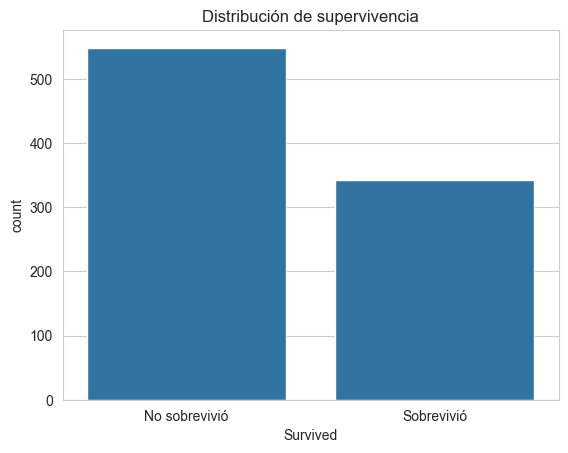

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

tasa_supervivencia = train['Survived'].mean()
print(f"Tasa de supervivencia: {tasa_supervivencia:.2%}")

sns.countplot(data=train, x='Survived')
plt.xticks([0, 1], ['No sobrevivió', 'Sobrevivió'])
plt.title('Distribución de supervivencia')
plt.show()

## 4. Supervivencia por variables categóricas (Sexo, Clase, Puerto de embarque)

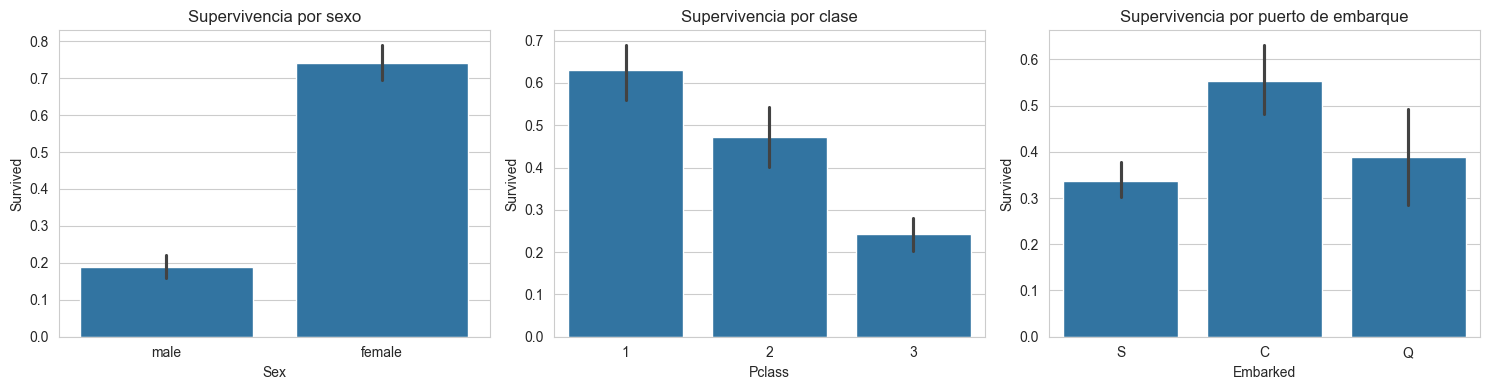

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0])
axes[0].set_title('Supervivencia por sexo')

sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[1])
axes[1].set_title('Supervivencia por clase')

sns.barplot(data=train, x='Embarked', y='Survived', ax=axes[2])
axes[2].set_title('Supervivencia por puerto de embarque')

plt.tight_layout()
plt.show()

print(train.groupby('Sex')['Survived'].mean())
print()
print(train.groupby('Pclass')['Survived'].mean())
print()
print(train.groupby('Embarked')['Survived'].mean())

## 5. Distribución de variables numéricas (Edad y Tarifa)

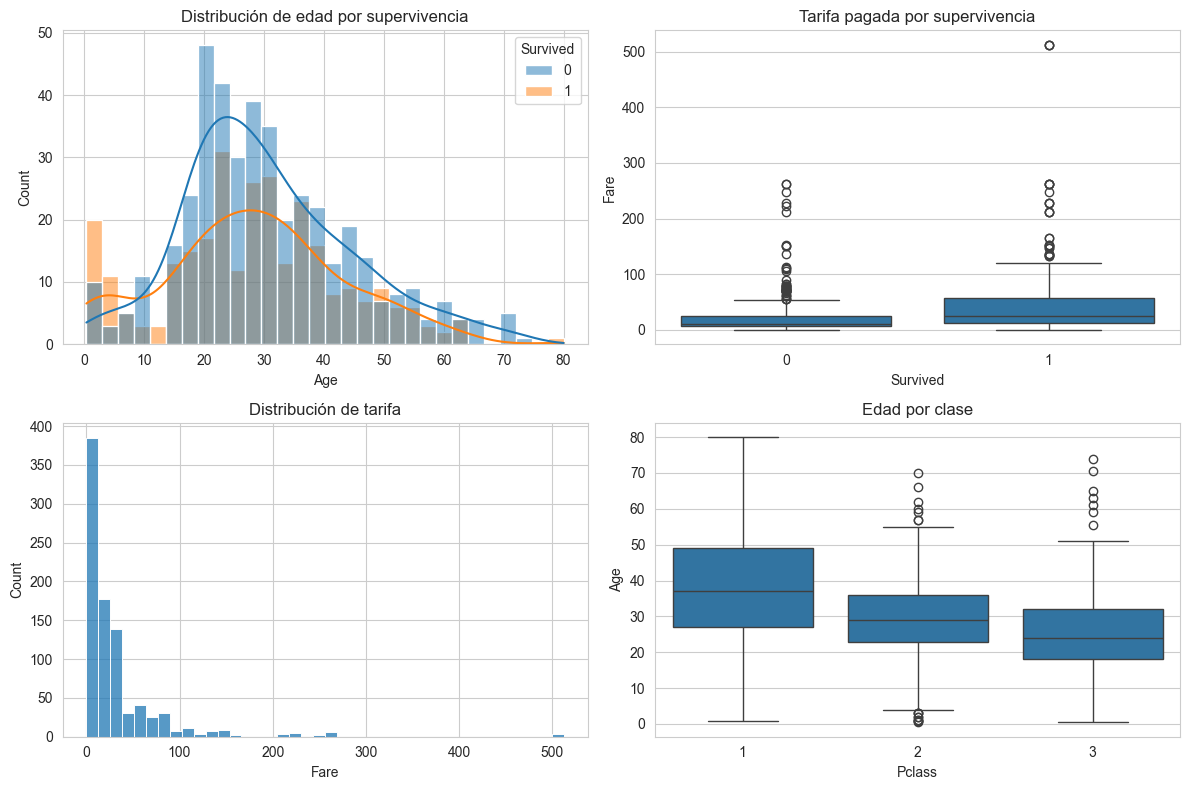

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(data=train, x='Age', hue='Survived', kde=True, bins=30, ax=axes[0, 0])
axes[0, 0].set_title('Distribución de edad por supervivencia')

sns.boxplot(data=train, x='Survived', y='Fare', ax=axes[0, 1])
axes[0, 1].set_title('Tarifa pagada por supervivencia')

sns.histplot(data=train, x='Fare', bins=40, ax=axes[1, 0])
axes[1, 0].set_title('Distribución de tarifa')

sns.boxplot(data=train, x='Pclass', y='Age', ax=axes[1, 1])
axes[1, 1].set_title('Edad por clase')

plt.tight_layout()
plt.show()

## 6. Familia a bordo (SibSp + Parch)

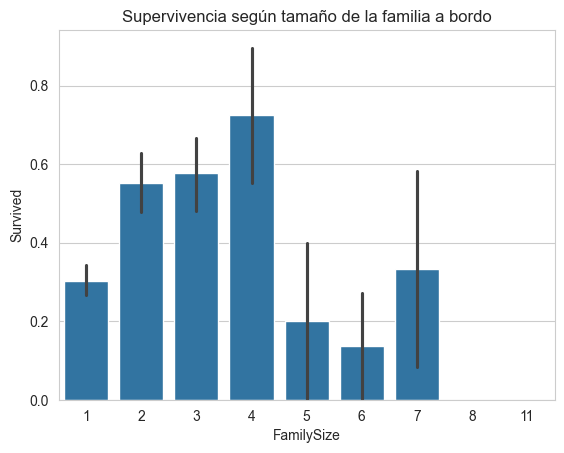

In [9]:
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1

sns.barplot(data=train, x='FamilySize', y='Survived')
plt.title('Supervivencia según tamaño de la familia a bordo')
plt.show()

## 7. Matriz de correlación

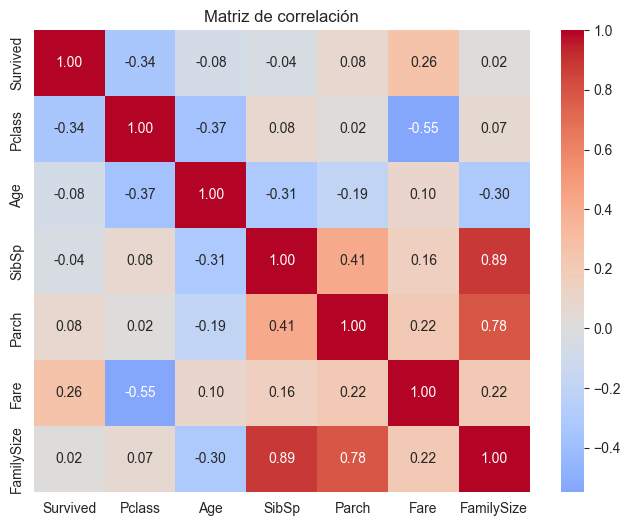

In [10]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
corr = train[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()